In [1]:
# ===============================================================
# 🧠 Step 1: Import Libraries
# ===============================================================
print("="*60)
print("🧠 STEP 1 START: Importing libraries...")
print("="*60)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import timedelta
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tcn import TCN

print("✅ STEP 1 COMPLETE: Libraries imported")



🧠 STEP 1 START: Importing libraries...


I0000 00:00:1772902161.652431  431994 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772902161.688471  431994 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ STEP 1 COMPLETE: Libraries imported


I0000 00:00:1772902162.549774  431994 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
df_hourly = pd.read_csv('cleandata.csv')
df_hourly.index = pd.to_datetime(df_hourly['timestamp'])
df_hourly.drop(columns=['timestamp'], inplace=True)

print("✅ STEP 2 COMPLETE: Hourly load")


✅ STEP 2 COMPLETE: Hourly load


In [3]:
df_hourly

,demand_kWh
timestamp,
2018-01-01 17:00:00,1.163317
2018-01-01 18:00:00,6.345366
2018-01-01 19:00:00,5.499317
2018-01-01 20:00:00,0.000000
2018-01-01 21:00:00,0.000000
...,...
2023-12-05 00:00:00,0.144595
2023-12-05 01:00:00,0.144595
2023-12-05 02:00:00,0.144595


In [4]:
# ===============================================================
# 🧠 Step 3: Transform Features
# ===============================================================
print("="*60)
print("🧠 STEP 3 START: Transforming datetime features...")
print("="*60)

df_hourly.index = pd.to_datetime(df_hourly.index)
df_hourly = df_hourly.sort_index()
df_hourly.index.name = "Datetime"

# Calendar features
df_hourly["hour"] = df_hourly.index.hour
df_hourly["day_of_week"] = df_hourly.index.dayofweek

# Cyclical encoding
df_hourly["hour_sin"] = np.sin(2 * np.pi * df_hourly["hour"] / 24)
df_hourly["hour_cos"] = np.cos(2 * np.pi * df_hourly["hour"] / 24)
df_hourly["day_sin"]  = np.sin(2 * np.pi * df_hourly["day_of_week"] / 7)
df_hourly["day_cos"]  = np.cos(2 * np.pi * df_hourly["day_of_week"] / 7)

print("✅ STEP 3 COMPLETE")

🧠 STEP 3 START: Transforming datetime features...
✅ STEP 3 COMPLETE


In [5]:
df_hourly

,demand_kWh,hour,day_of_week,hour_sin,hour_cos,day_sin,day_cos
Datetime,,,,,,,
2018-01-01 17:00:00,1.163317,17,0,-0.965926,-2.588190e-01,0.000000,1.00000
2018-01-01 18:00:00,6.345366,18,0,-1.000000,-1.836970e-16,0.000000,1.00000
2018-01-01 19:00:00,5.499317,19,0,-0.965926,2.588190e-01,0.000000,1.00000
2018-01-01 20:00:00,0.000000,20,0,-0.866025,5.000000e-01,0.000000,1.00000
2018-01-01 21:00:00,0.000000,21,0,-0.707107,7.071068e-01,0.000000,1.00000
...,...,...,...,...,...,...,...
2023-12-05 00:00:00,0.144595,0,1,0.000000,1.000000e+00,0.781831,0.62349
2023-12-05 01:00:00,0.144595,1,1,0.258819,9.659258e-01,0.781831,0.62349
2023-12-05 02:00:00,0.144595,2,1,0.500000,8.660254e-01,0.781831,0.62349


In [6]:
# ===============================================================
# 🧠 Step 4: Split Data by Year
# ===============================================================
print("="*60)
print("🧠 STEP 4 START: Splitting data into train / val / test...")
print("="*60)

data = df_hourly["demand_kWh"]
features = df_hourly[["hour_sin", "hour_cos", "day_sin", "day_cos"]]


train_mask = (df_hourly.index >= "2018-01-01") & (df_hourly.index < "2022-01-01")
val_mask   = (df_hourly.index >= "2021-01-01") & (df_hourly.index < "2022-01-01")
test_mask  = (df_hourly.index >= "2022-01-01") & (df_hourly.index < "2023-01-01")

train = data.loc[train_mask]
val   = data.loc[val_mask]
test  = data.loc[test_mask]

train_features = features.loc[train_mask]
val_features   = features.loc[val_mask]
test_features  = features.loc[test_mask]

print("Train range:", train.index.min(), "to", train.index.max())
print("Val range  :", val.index.min(), "to", val.index.max())
print("Test range :", test.index.min(), "to", test.index.max())

print("Train size:", len(train))
print("Val size  :", len(val))
print("Test size :", len(test))

print("✅ STEP 4 COMPLETE")

🧠 STEP 4 START: Splitting data into train / val / test...
Train range: 2018-01-01 17:00:00 to 2021-12-31 23:00:00
Val range  : 2021-01-01 00:00:00 to 2021-12-31 23:00:00
Test range : 2022-01-01 00:00:00 to 2022-12-31 23:00:00
Train size: 35047
Val size  : 8760
Test size : 8760
✅ STEP 4 COMPLETE


In [7]:
train_features

,hour_sin,hour_cos,day_sin,day_cos
Datetime,,,,
2018-01-01 17:00:00,-0.965926,-2.588190e-01,0.000000,1.000000
2018-01-01 18:00:00,-1.000000,-1.836970e-16,0.000000,1.000000
2018-01-01 19:00:00,-0.965926,2.588190e-01,0.000000,1.000000
2018-01-01 20:00:00,-0.866025,5.000000e-01,0.000000,1.000000
2018-01-01 21:00:00,-0.707107,7.071068e-01,0.000000,1.000000
...,...,...,...,...
2021-12-31 19:00:00,-0.965926,2.588190e-01,-0.433884,-0.900969
2021-12-31 20:00:00,-0.866025,5.000000e-01,-0.433884,-0.900969
2021-12-31 21:00:00,-0.707107,7.071068e-01,-0.433884,-0.900969


In [8]:
# ===============================================================
# 🧠 Step 5: Scale Data
# ===============================================================
print("="*60)
print("🧠 STEP 5 START: Scaling target...")
print("="*60)



y_scaler = StandardScaler()

y_train = y_scaler.fit_transform(train.values.reshape(-1,1))
y_val   = y_scaler.transform(val.values.reshape(-1,1))
y_test  = y_scaler.transform(test.values.reshape(-1,1))

# Sin/cos features are already bounded in [-1, 1], so keep as-is
X_train_feat = train_features.values
X_val_feat   = val_features.values
X_test_feat  = test_features.values

print("y_train shape:", y_train.shape)
print("y_val shape  :", y_val.shape)
print("y_test shape :", y_test.shape)

print("✅ STEP 5 COMPLETE")

🧠 STEP 5 START: Scaling target...
y_train shape: (35047, 1)
y_val shape  : (8760, 1)
y_test shape : (8760, 1)
✅ STEP 5 COMPLETE


In [9]:
# ===============================================================
# 🧠 Step 6: Create TCN Sequences (Sliding Window)
# ===============================================================
print("="*60)
print("🧠 STEP 6 START: Creating sliding-window sequences for TCN...")
print("="*60)

WINDOW_SIZE = 168 * 3
HORIZON = 168

def create_sliding_windows(y, X, window_size, horizon):
    X_seq, y_seq = [], []

    total_samples = len(y) - window_size - horizon + 1

    for start in tqdm(range(total_samples), desc="Building sliding windows"):
        end_window = start + window_size
        end_target = end_window + horizon

        y_window = y[start:end_window]                 # (window_size, 1)
        X_window = X[start:end_window]                 # (window_size, 4)

        window_features = np.hstack([y_window, X_window])   # (window_size, 5)
        target_window = y[end_window:end_target].reshape(-1)  # (horizon,)

        X_seq.append(window_features)
        y_seq.append(target_window)

    return np.array(X_seq), np.array(y_seq)

X_train, y_train_seq = create_sliding_windows(y_train, X_train_feat, WINDOW_SIZE, HORIZON)
X_val,   y_val_seq   = create_sliding_windows(y_val,   X_val_feat,   WINDOW_SIZE, HORIZON)
X_test,  y_test_seq  = create_sliding_windows(y_test,  X_test_feat,  WINDOW_SIZE, HORIZON)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train_seq.shape)
print("X_val shape  :", X_val.shape)
print("y_val shape  :", y_val_seq.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test_seq.shape)

print("✅ STEP 6 COMPLETE")

🧠 STEP 6 START: Creating sliding-window sequences for TCN...


Building sliding windows: 100%|██████████| 8089/8089 [00:00<00:00, 305994.26it/s]

X_train shape: (34376, 504, 5)
y_train shape: (34376, 168)
X_val shape  : (8089, 504, 5)
y_val shape  : (8089, 168)
X_test shape : (8089, 504, 5)
y_test shape : (8089, 168)
✅ STEP 6 COMPLETE


In [10]:
X_train[1]

array([[-5.00275328e-01, -1.00000000e+00, -1.83697020e-16,
         0.00000000e+00,  1.00000000e+00],
       [-5.48346573e-01, -9.65925826e-01,  2.58819045e-01,
         0.00000000e+00,  1.00000000e+00],
       [-8.60809665e-01, -8.66025404e-01,  5.00000000e-01,
         0.00000000e+00,  1.00000000e+00],
       ...,
       [-3.85678655e-01, -7.07106781e-01, -7.07106781e-01,
         0.00000000e+00,  1.00000000e+00],
       [-4.70858082e-01, -8.66025404e-01, -5.00000000e-01,
         0.00000000e+00,  1.00000000e+00],
       [-5.14455504e-01, -9.65925826e-01, -2.58819045e-01,
         0.00000000e+00,  1.00000000e+00]])

In [11]:
y_train_seq

array([[-0.5144555 , -0.57884614, -0.83640868, ..., -0.15024329,
        -0.73143284, -0.8493392 ],
       [-0.57884614, -0.83640868, -0.83640868, ..., -0.73143284,
        -0.8493392 , -0.8493392 ],
       [-0.83640868, -0.83640868, -0.83640868, ..., -0.8493392 ,
        -0.8493392 , -0.8493392 ],
       ...,
       [-0.86080967, -0.86080967, -0.1945573 , ...,  0.18877225,
         0.41318778, -0.29363045],
       [-0.86080967, -0.1945573 , -0.14696785, ...,  0.41318778,
        -0.29363045, -0.86080967],
       [-0.1945573 , -0.14696785, -0.14696785, ..., -0.29363045,
        -0.86080967, -0.86080967]])

In [12]:
# ===============================================================
# 🧠 Step 6: Build TCN-Only Model
# ===============================================================
print("="*60)
print("🧠 STEP 6 START: Building TCN model...")
print("="*60)

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    TCN(
        nb_filters=64,
        kernel_size=3,
        dilations=[1, 2, 4, 8, 16, 32, 64],
        dropout_rate=0.3,
        return_sequences=False
    ),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(HORIZON)
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mse','mae']
)

model.summary()
print("✅ STEP 6 COMPLETE")


I0000 00:00:1772902163.532389  431994 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20882 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


🧠 STEP 6 START: Building TCN model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tcn (TCN)                       │ (None, 64)             │       161,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 168)            │        10,920 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,064 (691.66 KB)

 Trainable params: 177,064 (691.66 KB)

 Non-trainable params: 0 (0.00 B)

✅ STEP 6 COMPLETE


In [13]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
# ===============================================================
# 🧠 Step 7: Train the TCN Model
# ===============================================================
print("="*60)
print("🧠 STEP 7 START: Training TCN...")
print("="*60)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True,
    verbose=1
)


history = model.fit(
    X_train,
    y_train_seq,
    validation_data=(X_val, y_val_seq),
    epochs=300,
    batch_size=32,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)

print("✅ STEP 7 COMPLETE")

🧠 STEP 7 START: Training TCN...
Epoch 1/300


I0000 00:00:1772902166.901541  432083 service.cc:153] XLA service 0x7ce6a0048c20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772902166.901556  432083 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090, Compute Capability 8.9 (Driver: 12.8.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1772902166.974284  432083 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1772902167.576425  432083 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1772902167.792669  432083 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8494__.39
I0000 00:00:1772902168.597075  432083 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I00

  31/1075 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 1390.1818 - mae: 27.5147 - mse: 1390.1818 

I0000 00:00:1772902178.344471  432083 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1066/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 157.5599 - mae: 6.6505 - mse: 157.5599

I0000 00:00:1772902184.939342  432081 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8494__.39


1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 156.5862 - mae: 6.6230 - mse: 156.5862

I0000 00:00:1772902194.190465  432084 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1772902194.481265  433470 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_6', 168 bytes spill stores, 168 bytes spill loads

I0000 00:00:1772902196.561833  432081 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1772902196.699196  433559 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 24 bytes spill stores, 24 bytes spill loads

I0000 00:00:1772902196.835

1075/1075 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - loss: 41.1434 - mae: 3.3644 - mse: 41.1434 - val_loss: 1.6598 - val_mae: 0.9793 - val_mse: 1.6598
Epoch 2/300
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2.1810 - mae: 1.1440 - mse: 2.1810 - val_loss: 1.6096 - val_mae: 0.9673 - val_mse: 1.6096
Epoch 3/300
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.3863 - mae: 0.9125 - mse: 1.3863 - val_loss: 1.6036 - val_mae: 0.9665 - val_mse: 1.6036
Epoch 4/300
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.1612 - mae: 0.8383 - mse: 1.1612 - val_loss: 1.6032 - val_mae: 0.9670 - val_mse: 1.6032
Epoch 5/300
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.0737 - mae: 0.8098 - mse: 1.0737 - val_loss: 1.6034 - val_mae: 0.9676 - val_mse: 1.6034
Epoch 6/300
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.0371 - mae: 0.7987 - mse: 1.0371 - val_loss: 1.6030 - val_mae: 0.9678 - val_mse: 1.6030
Epoch 7/300
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 1.0214 - mae: 0.7942 - mse:

📊 STEP 8 START: Plotting training history...


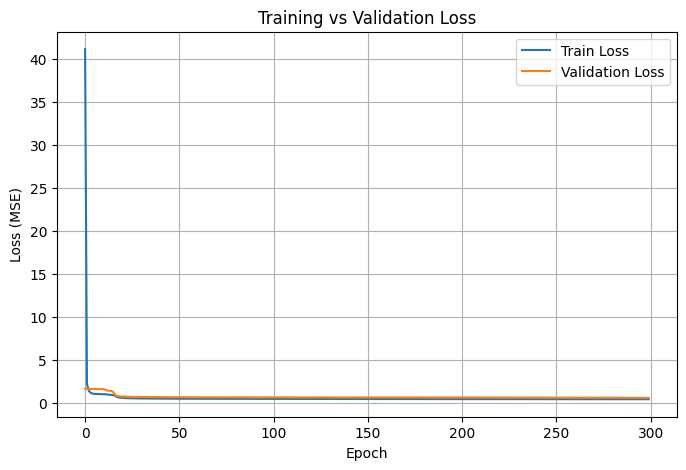

✅ STEP 8 COMPLETE


In [15]:
# ===============================================================
# 📊 Step 8: Plot Training Loss per Epoch
# ===============================================================
print("="*60)
print("📊 STEP 8 START: Plotting training history...")
print("="*60)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

print("✅ STEP 8 COMPLETE")

In [16]:
# ===============================================================
# 🧠 Step 8: Make Predictions on Test Set
# ===============================================================
print("="*60)
print("🧠 STEP 8 START: Generating predictions on TEST set...")
print("="*60)

# Predict scaled values
y_pred_scaled = model.predict(X_test)

# Save shapes
n_samples = y_pred_scaled.shape[0]
horizon = y_pred_scaled.shape[1]

# Inverse transform predictions
y_pred = y_scaler.inverse_transform(
    y_pred_scaled.reshape(-1,1)
).reshape(n_samples, horizon)

# Inverse transform ground truth
y_true = y_scaler.inverse_transform(
    y_test_seq.reshape(-1,1)
).reshape(n_samples, horizon)

print("Prediction shape:", y_pred.shape)
print("True shape:", y_true.shape)

print("✅ STEP 8 COMPLETE")

🧠 STEP 8 START: Generating predictions on TEST set...
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Prediction shape: (8089, 168)
True shape: (8089, 168)
✅ STEP 8 COMPLETE


In [17]:
# ===============================================================
# 🧠 Step 9: Model Evaluation on Test Set
# ===============================================================
print("="*60)
print("🧠 STEP 9 START: Evaluating model on TEST set...")
print("="*60)

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Flatten all forecast horizons for overall evaluation
y_true_flat = y_true.reshape(-1)
y_pred_flat = y_pred.reshape(-1)

# --- Core error metrics ---
mae = mean_absolute_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
r2 = r2_score(y_true_flat, y_pred_flat)

# --- SMAPE implementation ---
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred) / np.maximum(denominator, 1e-8)
    return np.mean(diff) * 100

smape_value = smape(y_true_flat, y_pred_flat)

# --- Print results ---
print("Overall multi-step test metrics:")
print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"R²    : {r2:.4f}")
print(f"SMAPE : {smape_value:.2f}%")

print("✅ STEP 9 COMPLETE")

🧠 STEP 9 START: Evaluating model on TEST set...
Overall multi-step test metrics:
MAE   : 18.6330
RMSE  : 26.5476
R²    : 0.3646
SMAPE : 64.40%
✅ STEP 9 COMPLETE


In [18]:
# --- First-step-ahead metrics only ---
mae_t1 = mean_absolute_error(y_true[:, 0], y_pred[:, 0])
rmse_t1 = np.sqrt(mean_squared_error(y_true[:, 0], y_pred[:, 0]))
r2_t1 = r2_score(y_true[:, 0], y_pred[:, 0])
smape_t1 = smape(y_true[:, 0], y_pred[:, 0])

print("\nStep-1 ahead metrics:")
print(f"MAE   : {mae_t1:.4f}")
print(f"RMSE  : {rmse_t1:.4f}")
print(f"R²    : {r2_t1:.4f}")
print(f"SMAPE : {smape_t1:.2f}%")


Step-1 ahead metrics:
MAE   : 17.7596
RMSE  : 25.3488
R²    : 0.4200
SMAPE : 61.94%


📊 STEP 10 START: Plotting first-step-ahead forecast...


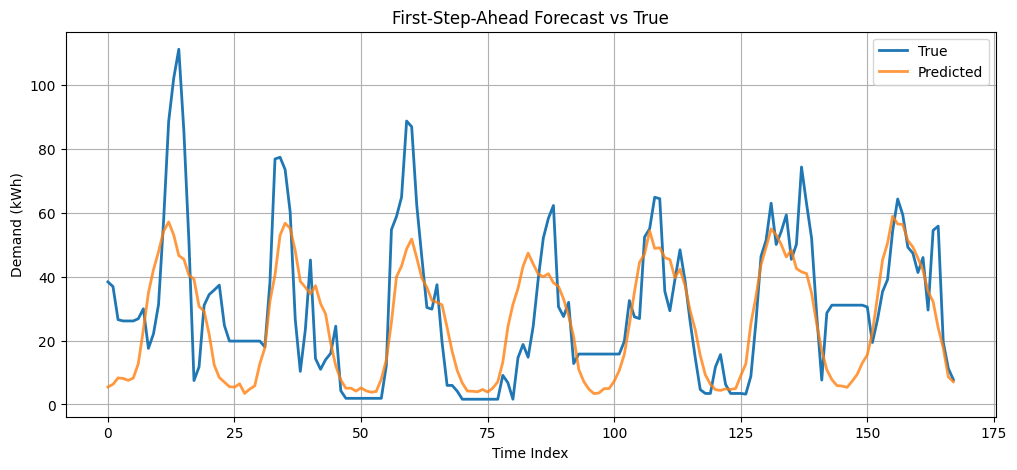

✅ STEP 10 COMPLETE


In [19]:
# ===============================================================
# 📊 Step 10: Plot First-Step-Ahead Forecast vs True
# ===============================================================
print("="*60)
print("📊 STEP 10 START: Plotting first-step-ahead forecast...")
print("="*60)

import matplotlib.pyplot as plt

# first-step ahead prediction
y_true_t1 = y_true[:168,0]
y_pred_t1 = y_pred[:168,0]

plt.figure(figsize=(12,5))

plt.plot(y_true_t1, label='True', linewidth=2)
plt.plot(y_pred_t1, label='Predicted', linewidth=2, alpha=0.8)

plt.title("First-Step-Ahead Forecast vs True")
plt.xlabel("Time Index")
plt.ylabel("Demand (kWh)")
plt.legend()
plt.grid(True)

plt.show()

print("✅ STEP 10 COMPLETE")

📊 STEP 10 START: Plotting first full-horizon forecast...


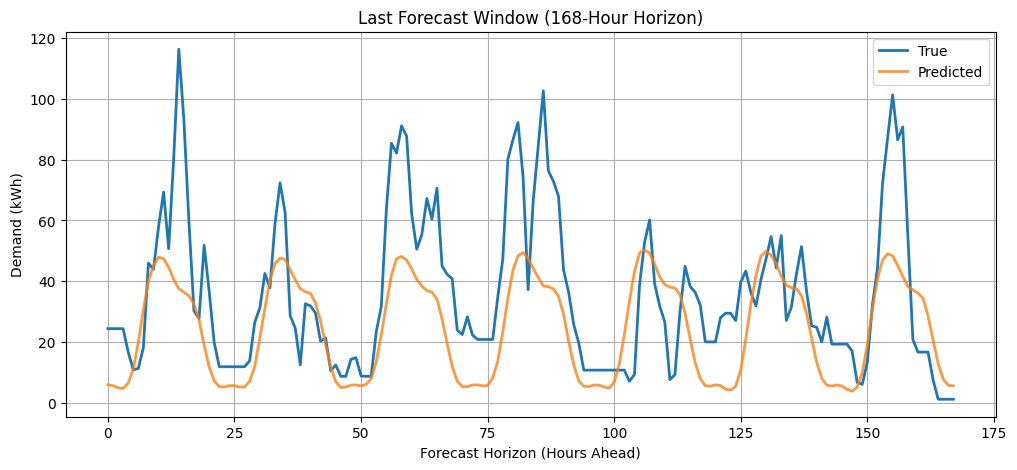

✅ STEP 10 COMPLETE


In [20]:
# ===============================================================
# 📊 Step 10: Plot First Forecast Window (Full Horizon)
# ===============================================================
print("="*60)
print("📊 STEP 10 START: Plotting first full-horizon forecast...")
print("="*60)

import matplotlib.pyplot as plt
import numpy as np

# first prediction window
y_true_h = y_true[-HORIZON]
y_pred_h = y_pred[-HORIZON]

horizon = len(y_true_h)
t = np.arange(horizon)

plt.figure(figsize=(12,5))

plt.plot(t, y_true_h, label="True", linewidth=2)
plt.plot(t, y_pred_h, label="Predicted", linewidth=2, alpha=0.8)

plt.title("Last Forecast Window (168-Hour Horizon)")
plt.xlabel("Forecast Horizon (Hours Ahead)")
plt.ylabel("Demand (kWh)")
plt.legend()
plt.grid(True)

plt.show()

print("✅ STEP 10 COMPLETE")

In [21]:
# ===============================================================
# 🧠 Step 11: Save Model (For Thesis Reproducibility)
# ======================================a=========================
#FIX 1 (RECOMMENDED): Use the native Keras format
print("="*60)
print("🧠 STEP 11 START: Saving model (Keras format)...")
print("="*60)

model.save("TCN_only_model.keras")

print("✅ STEP 11 COMPLETE — PIPELINE FINISHED SUCCESSFULLY")
print("="*60)


🧠 STEP 11 START: Saving model (Keras format)...


✅ STEP 11 COMPLETE — PIPELINE FINISHED SUCCESSFULLY


In [22]:
#FIX 2 (ALSO VALID): Save weights only (most robust)

print("="*60)
print("🧠 STEP 11 START: Saving model weights only...")
print("="*60)

model.save_weights("TCN_only_weights.weights.h5")

print("✅ STEP 11 COMPLETE — PIPELINE FINISHED SUCCESSFULLY")
print("="*60)


🧠 STEP 11 START: Saving model weights only...
✅ STEP 11 COMPLETE — PIPELINE FINISHED SUCCESSFULLY
